In [16]:
# k-means 알고리즘으로 붓꽃 품종 구분하기

In [17]:
from sklearn.datasets import load_iris
iris = load_iris()

import pandas as pd

In [18]:
from sklearn.cluster import KMeans
iris_df = pd.DataFrame(data=iris.data, columns=['sepal_length','sepal_width','petal_length','petal_width'])
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [19]:
KM = KMeans(n_clusters=3, init='k-means++',max_iter=300, random_state =0)
KM.fit(iris_df)

c:\Users\Admin\miniconda3\envs\hi_ml_env\lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


KMeans(n_clusters=3, random_state=0)

In [20]:
iris_df['target'] = iris.target
iris_df['cluster'] = KM.labels_
iris_df.groupby(['target','cluster'])['sepal_length'].count()


target  cluster
0       1          50
1       0          47
        2           3
2       0          14
        2          36
Name: sepal_length, dtype: int64

target: 실제 품종 라벨 (0=setosa, 1=versicolor, 2=virginica)

cluster: KMeans가 분류한 군집 번호 (0, 1, 2 중 하나)

값: 해당 target과 cluster 조합에서의 표본 수 (sepal_length 개수 = 개체 수)

# silhouette 계수 측정

실루엣 계수: 개별 데이터가 자신의 클러스터 내에 얼마나 잘 속해있는지, </br>그리고 다른 클러스터와 얼마나 잘 분리되어 있는지를 측정하는 지표

In [23]:
from sklearn.metrics import silhouette_samples, silhouette_score
score_samples = silhouette_samples(iris.data,iris_df['cluster'])
iris_df['silhouette_coeff'] = score_samples
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,target,cluster,silhouette_coeff
0,5.1,3.5,1.4,0.2,0,1,0.852582
1,4.9,3.0,1.4,0.2,0,1,0.814916
2,4.7,3.2,1.3,0.2,0,1,0.828797
3,4.6,3.1,1.5,0.2,0,1,0.804352
4,5.0,3.6,1.4,0.2,0,1,0.848918


In [22]:
silhouette_score(iris.data,iris_df['cluster'])

np.float64(0.5511916046195919)

# 실루엣 차트

In [25]:
import matplotlib.pyplot as plt

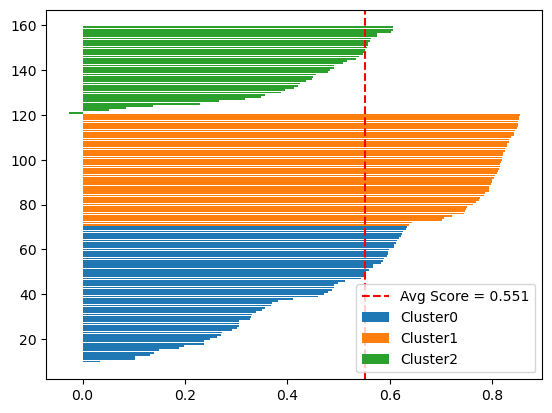

In [27]:
y_lower = 10
for i in range(3):
    cluster_i = score_samples[iris_df['cluster']==i]
    cluster_i.sort()
    y_upper = y_lower + len(cluster_i)
    plt.barh(range(y_lower, y_upper), cluster_i, label=f'Cluster{i}')
    y_lower = y_upper
    
avg_score = silhouette_score(iris.data, iris_df['cluster'])
plt.axvline(avg_score, color='red', linestyle='--', label=f'Avg Score = {avg_score:.3f}')
plt.legend()
plt.show()
    